In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pathlib import Path
import warnings
data_dir = Path("cleaned_data")
spark = SparkSession.builder \
.appName("Read Parquet") \
    .config("spark.driver.memory", "12g")\
        .getOrCreate()

yellow_taxi = spark.read.parquet(f"{data_dir / 'yellow_data.parquet'}")
yellow_taxi = yellow_taxi.filter(F.col('date') < '2026-01-01')
fhvhv_taxi = spark.read.parquet(f"{data_dir / 'fhvhv_data.parquet'}")
fhvhv_taxi = fhvhv_taxi.filter(F.col('date') < '2026-01-01')
warnings.filterwarnings("ignore", module="pyspark")
yellow_taxi.show(1)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/31 19:13:08 WARN Utils: Your hostname, aydin-khan-desktop, resolves to a loopback address: 127.0.1.1; using 192.168.1.18 instead (on interface wlp11s0)
26/08/31 19:13:08 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/08/31 19:13:09 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where app

+-------------------+------------+------------+-------+
|               date|PULocationID|total_amount|Borough|
+-------------------+------------+------------+-------+
|2023-05-01 00:33:13|         138|       51.65| Queens|
+-------------------+------------+------------+-------+
only showing top 1 row


In [2]:
fhvhv_taxi.show(1)

+-------------------+------------+
|               date|PULocationID|
+-------------------+------------+
|2023-03-01 00:05:26|         114|
+-------------------+------------+
only showing top 1 row


In [3]:
print('Shape:', (yellow_taxi.count(), len(yellow_taxi.columns)))
daily_taxi_earnings = (
    yellow_taxi
    .withColumn("day", F.to_date("date"))
    .groupBy("day", "PULocationID")
    .agg(F.sum("total_amount").alias("total_amount"))
    .orderBy("day", "PULocationID")
)
print('Shape:', (daily_taxi_earnings.count(), len(daily_taxi_earnings.columns)))

Shape: (127565947, 4)


Shape: (252062, 3)


Shape before grouping: (252062, 3)


Shape after grouping: (1096, 2)


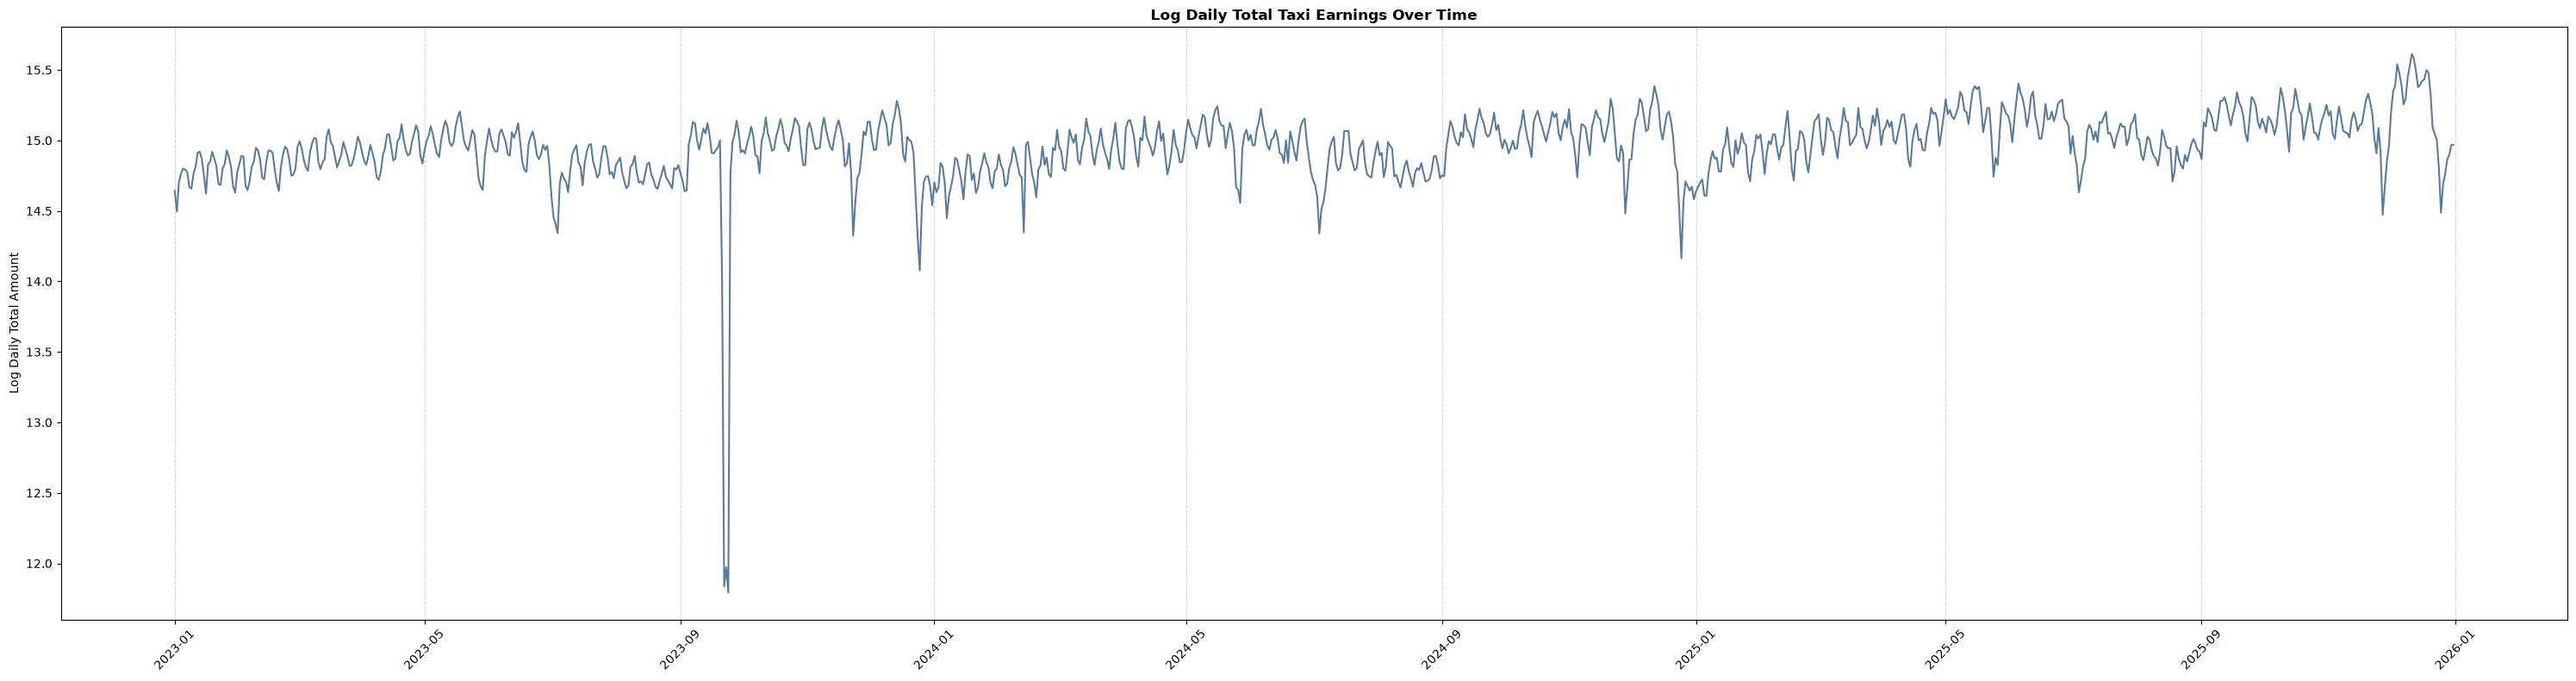

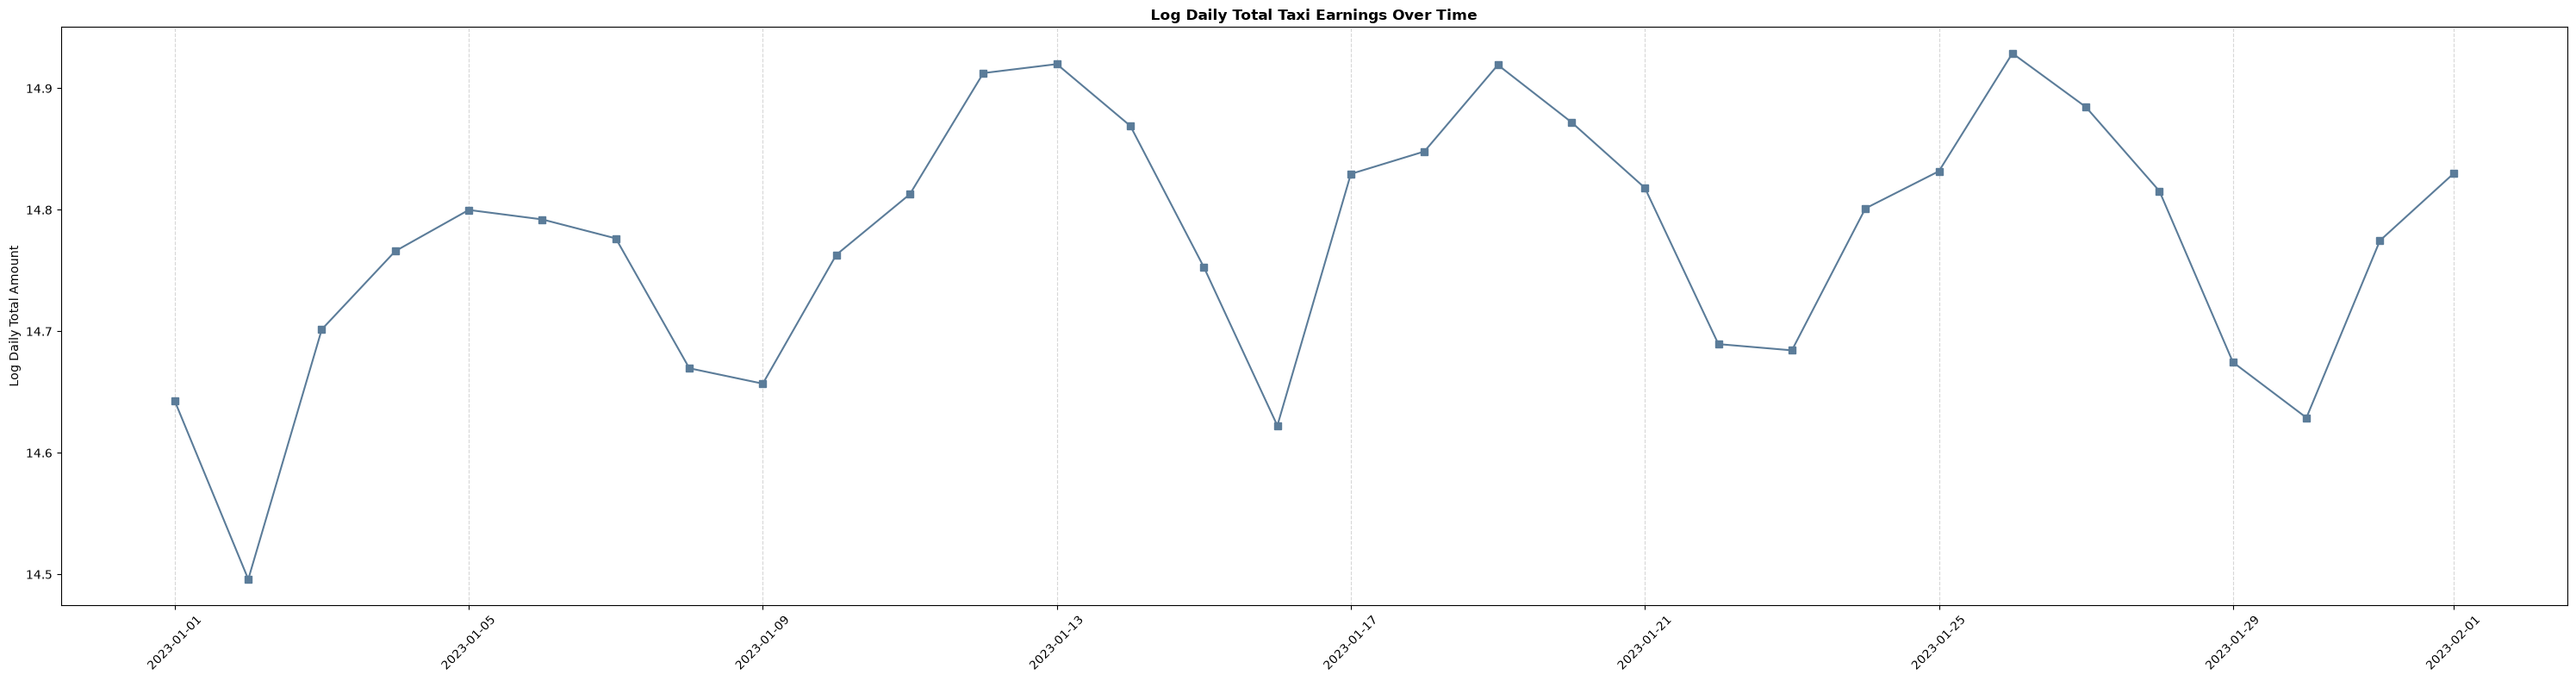

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Group by day and calculate daily total taxi earnings
print('Shape before grouping:', (daily_taxi_earnings.count(), len(daily_taxi_earnings.columns)))
daily_total_taxi_earnings = daily_taxi_earnings.groupby("day").agg(
    F.sum("total_amount").alias("daily_total_amount")
)
print('Shape after grouping:', (daily_total_taxi_earnings.count(), len(daily_total_taxi_earnings.columns)))

# Calculate log of daily total amount
daily_total_taxi_earnings = daily_total_taxi_earnings.withColumn(
    "log_daily_total_amount",
    F.log("daily_total_amount")
)

# Convert to Pandas once
plot_df = daily_total_taxi_earnings.select(
    "day", "log_daily_total_amount"
).toPandas()

# Sort by day
plot_df = plot_df.sort_values("day")
plot_df["day"] = pd.to_datetime(plot_df["day"])

# Create images directory if it doesn't exist
os.makedirs("images", exist_ok=True)

# Muted blue
line_colour = "#5B7C99"

# --------------------------------------------------
# First plot: all dates
# --------------------------------------------------
plot_df_left = plot_df

fig, ax = plt.subplots(figsize=(30, 8))

ax.plot(
    plot_df_left["day"],
    plot_df_left["log_daily_total_amount"],
    color=line_colour
)

ax.set_xlabel("")
ax.set_ylabel("Log Daily Total Amount")
ax.set_title(
    "Log Daily Total Taxi Earnings Over Time",
    fontweight="bold"
)
ax.tick_params(axis="x", rotation=45)

# Vertical grid lines only
ax.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(
    "images/log_daily_total_taxi_earnings_all_dates.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close(fig)


# --------------------------------------------------
# Second plot: day <= "2023-02-01"
# --------------------------------------------------
plot_df_right = plot_df[
    plot_df["day"] <= pd.Timestamp("2023-02-01")
]

fig, ax = plt.subplots(figsize=(30, 8))

ax.plot(
    plot_df_right["day"],
    plot_df_right["log_daily_total_amount"],
    color=line_colour,
    marker="s"
)

ax.set_xlabel("")
ax.set_ylabel("Log Daily Total Amount")
ax.set_title(
    "Log Daily Total Taxi Earnings Over Time",
    fontweight="bold"
)
ax.tick_params(axis="x", rotation=45)

# Vertical grid lines only
ax.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(
    "images/log_daily_total_taxi_earnings_to_2023-02-01.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close(fig)

In [22]:
import geopandas as gpd
geo_data = gpd.read_file("data/taxi_zones/taxi_zones.shp")
geo_data.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Shape before grouping: (96567831, 4)


Shape after grouping: (260, 4)
Shape before grouping: (96567831, 4)


Shape after grouping: (6, 2)


Shape before dropping nulls and duplicates: (260, 4)
Shape after dropping nulls and duplicates: (260, 4)
Shape before preparing boxplot data: (260, 4)
Shape after preparing boxplot data: (260, 4)


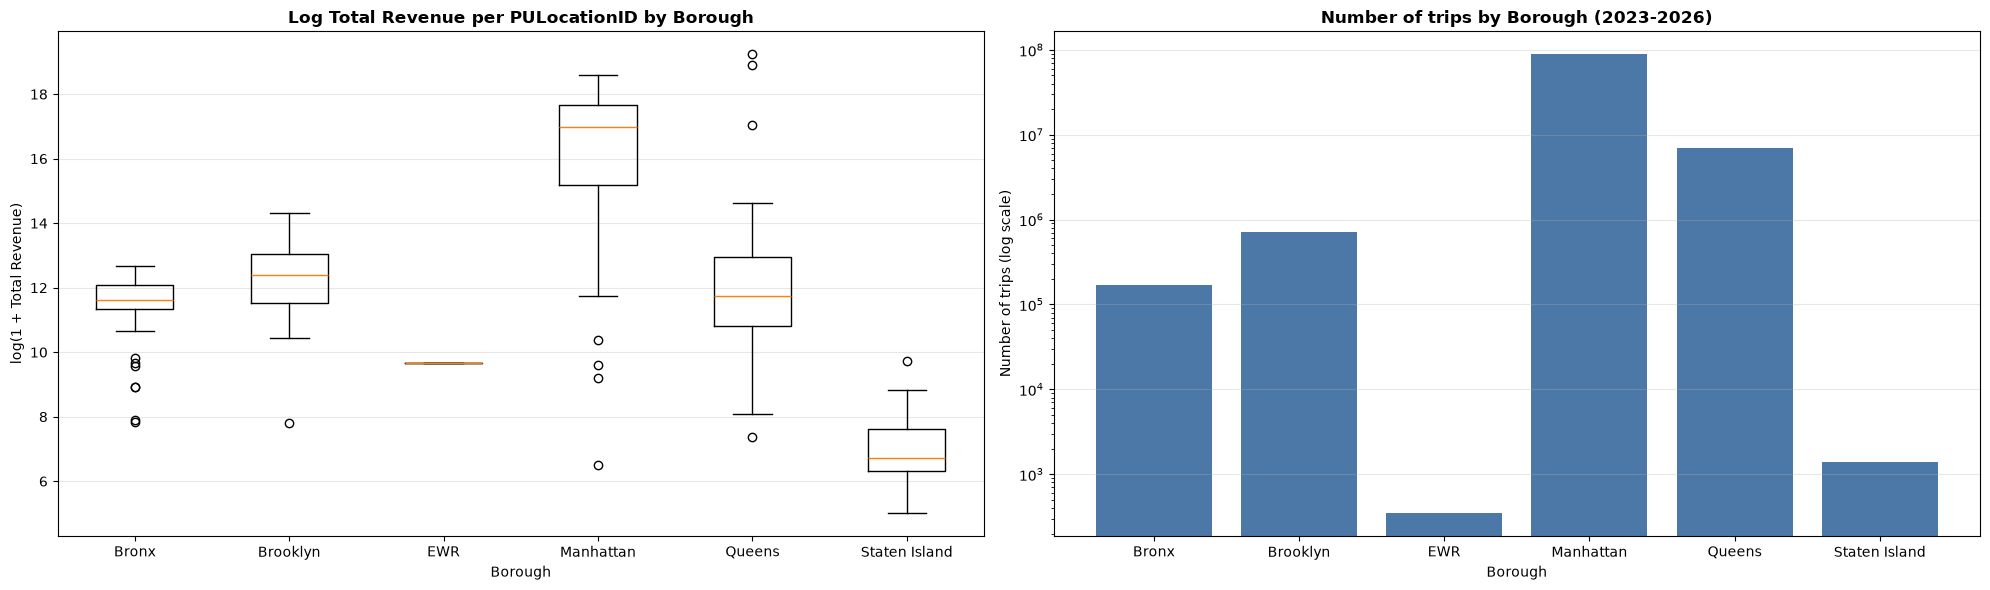

In [23]:
import matplotlib.pyplot as plt
# --------------------------------------------------
# Step 3: Total revenue for each PULocationID
# over the ENTIRE time period
# --------------------------------------------------

print('Shape before grouping:', (yellow_taxi.count(), len(yellow_taxi.columns)))
location_total_revenue = (
    yellow_taxi
    .groupBy("PULocationID", "Borough")
    .agg(
        F.sum("total_amount").alias("total_revenue")
    )
    .withColumn(
        "log_total_revenue",
        F.log1p("total_revenue")
    )
)
print('Shape after grouping:', (location_total_revenue.count(), len(location_total_revenue.columns)))


# --------------------------------------------------
# Step 4: Count number of trips for each Borough
# --------------------------------------------------
print('Shape before grouping:', (yellow_taxi.count(), len(yellow_taxi.columns)))
borough_trip_counts = (
    yellow_taxi
    .groupBy("Borough")
    .agg(
        F.count("*").alias("number_of_trips")
    )
    .orderBy("Borough")
)
print('Shape after grouping:', (borough_trip_counts.count(), len(borough_trip_counts.columns)))


# --------------------------------------------------
# Step 5: Convert both results to Pandas
# --------------------------------------------------

location_total_revenue_pd = location_total_revenue.toPandas()
borough_trip_counts_pd = borough_trip_counts.toPandas()


# --------------------------------------------------
# Step 6: Prepare boxplot data
# --------------------------------------------------
print('Shape before dropping nulls and duplicates:', location_total_revenue_pd.shape)
boroughs = sorted(
    location_total_revenue_pd["Borough"]
    .dropna()
    .unique()
)
print('Shape after dropping nulls and duplicates:', location_total_revenue_pd.shape)

print('Shape before preparing boxplot data:', location_total_revenue_pd.shape)
boxplot_data = [
    location_total_revenue_pd.loc[
        location_total_revenue_pd["Borough"] == borough,
        "log_total_revenue"
    ].dropna()
    for borough in boroughs
]
print('Shape after preparing boxplot data:', location_total_revenue_pd.shape)


# --------------------------------------------------
# Step 7: Create 1x2 subplot
# --------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(20, 6)
)


# ==================================================
# LEFT: Boxplot of log total revenue
# ==================================================

axes[0].boxplot(
    boxplot_data,
    tick_labels=boroughs
)

axes[0].set_title(
    "Log Total Revenue per PULocationID by Borough",
    fontweight="bold"
)

axes[0].set_xlabel("Borough")
axes[0].set_ylabel("log(1 + Total Revenue)")
axes[0].grid(axis="y", alpha=0.3)


# ==================================================
# RIGHT: Number of trips by Borough
# ==================================================

axes[1].bar(
    borough_trip_counts_pd["Borough"],
    borough_trip_counts_pd["number_of_trips"],
    color='#4C78A8'
)

axes[1].set_title(
    "Number of trips by Borough (2023-2026)",
    fontweight="bold"
)

axes[1].set_xlabel("Borough")
axes[1].set_ylabel("Number of trips (log scale)")
axes[1].set_yscale("log")
axes[1].grid(axis="y", alpha=0.3)


# --------------------------------------------------
# Final formatting
# --------------------------------------------------

plt.tight_layout()
plt.show()

In [24]:
# create a new column called trip_volume which is the the number of trips per PULocationID per day
print('Shape before grouping:', (fhvhv_taxi.count(), len(fhvhv_taxi.columns)))
fhvhv_trip_volume = (
    fhvhv_taxi
    .withColumn("date", F.to_date("date"))
    .groupBy("PULocationID", "date")
    .agg(F.count("*").alias("trip_volume"))
)
print('Shape after grouping:', (fhvhv_trip_volume.count(), len(fhvhv_trip_volume.columns)))
fhvhv_trip_volume.show(5)

Shape before grouping: (715380596, 2)


Shape after grouping: (281758, 3)


+------------+----------+-----------+
|PULocationID|      date|trip_volume|
+------------+----------+-----------+
|          50|2023-03-01|       3391|
|         223|2023-03-01|       2608|
|         248|2023-03-03|       1954|
|         247|2023-03-04|       3538|
|         109|2023-03-06|        343|
+------------+----------+-----------+
only showing top 5 rows


Shape before grouping: (96567831, 4)
Shape after grouping: (260, 2)


Shape before grouping: (281758, 3)


Shape after grouping: (260, 2)


Shape before merging: (263, 7)
Shape after merging: (263, 9)
Shape before merging: (263, 7)
Shape after merging: (263, 9)


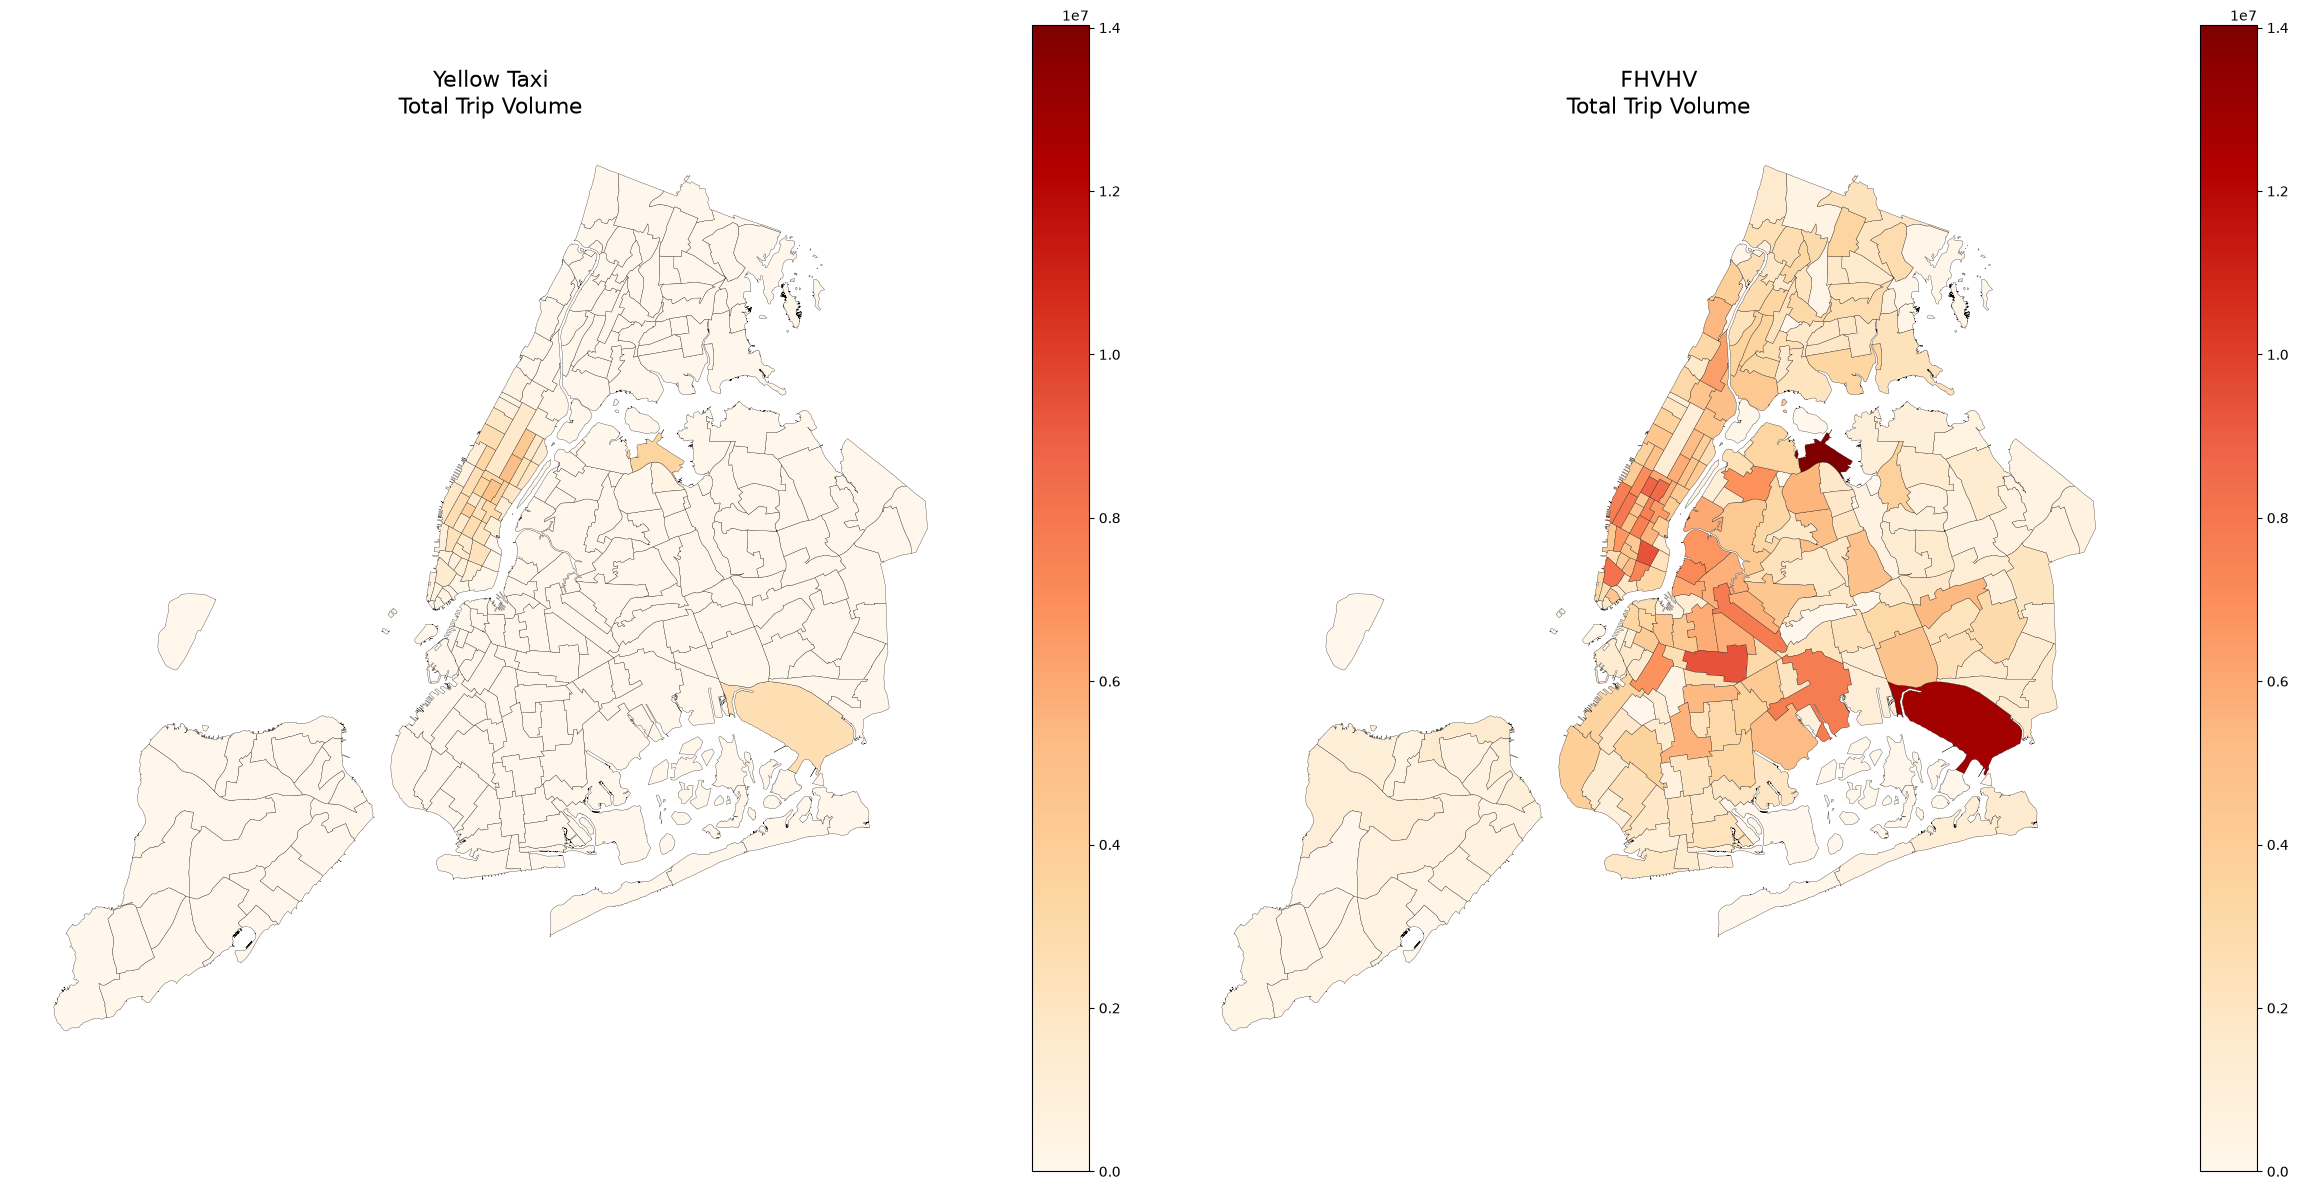

In [25]:
# ---------------------------------------------------------
# 1. Yellow Taxi: count trips across ALL dates
# ---------------------------------------------------------
print('Shape before grouping:', (yellow_taxi.count(), len(yellow_taxi.columns)))
yellow_total = (
    yellow_taxi
    .groupBy("PULocationID")
    .count()
    .withColumnRenamed("count", "trip_volume")
)
print('Shape after grouping:', (yellow_total.count(), len(yellow_total.columns)))

yellow_pd = yellow_total.toPandas()


# ---------------------------------------------------------
# 2. FHVHV: sum trip volume across ALL dates
# ---------------------------------------------------------
print('Shape before grouping:', (fhvhv_trip_volume.count(), len(fhvhv_trip_volume.columns)))
fhvhv_total = (
    fhvhv_trip_volume
    .groupBy("PULocationID")
    .sum("trip_volume")
    .withColumnRenamed("sum(trip_volume)", "trip_volume")
)
print('Shape after grouping:', (fhvhv_total.count(), len(fhvhv_total.columns)))

fhvhv_pd = fhvhv_total.toPandas()


# ---------------------------------------------------------
# 3. Load NYC Taxi Zone shapefile
# ---------------------------------------------------------
taxi_zones = gpd.read_file("data/taxi_zones/taxi_zones.shp")

taxi_zones["LocationID"] = taxi_zones["LocationID"].astype(int)

yellow_pd["PULocationID"] = yellow_pd["PULocationID"].astype(int)
fhvhv_pd["PULocationID"] = fhvhv_pd["PULocationID"].astype(int)


# ---------------------------------------------------------
# 4. Join trip volumes to the geographic zones
# ---------------------------------------------------------
print('Shape before merging:', (taxi_zones.shape[0], len(taxi_zones.columns)))
yellow_map = taxi_zones.merge(
    yellow_pd,
    left_on="LocationID",
    right_on="PULocationID",
    how="left"
)
print('Shape after merging:', (yellow_map.shape[0], len(yellow_map.columns)))

print('Shape before merging:', (taxi_zones.shape[0], len(taxi_zones.columns)))
fhvhv_map = taxi_zones.merge(
    fhvhv_pd,
    left_on="LocationID",
    right_on="PULocationID",
    how="left"
)
print('Shape after merging:', (fhvhv_map.shape[0], len(fhvhv_map.columns)))

# Zones with no trips get 0
yellow_map["trip_volume"] = yellow_map["trip_volume"].fillna(0)
fhvhv_map["trip_volume"] = fhvhv_map["trip_volume"].fillna(0)


# ---------------------------------------------------------
# 5. SAME color scale for both maps
# ---------------------------------------------------------
vmin = min(
    yellow_map["trip_volume"].min(),
    fhvhv_map["trip_volume"].min()
)

vmax = max(
    yellow_map["trip_volume"].max(),
    fhvhv_map["trip_volume"].max()
)


# ---------------------------------------------------------
# 6. Create side-by-side choropleth maps
# ---------------------------------------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(24, 12)
)

# Yellow Taxi
yellow_map.plot(
    column="trip_volume",
    cmap="OrRd",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    vmin=vmin,
    vmax=vmax,
    ax=axes[0],
    missing_kwds={"color": "lightgrey"}
)

axes[0].set_title(
    "Yellow Taxi\nTotal Trip Volume",
    fontsize=16
)
axes[0].axis("off")


# FHVHV
fhvhv_map.plot(
    column="trip_volume",
    cmap="OrRd",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    vmin=vmin,
    vmax=vmax,
    ax=axes[1],
    missing_kwds={"color": "lightgrey"}
)

axes[1].set_title(
    "FHVHV\nTotal Trip Volume",
    fontsize=16
)
axes[1].axis("off")


plt.tight_layout()
plt.show()

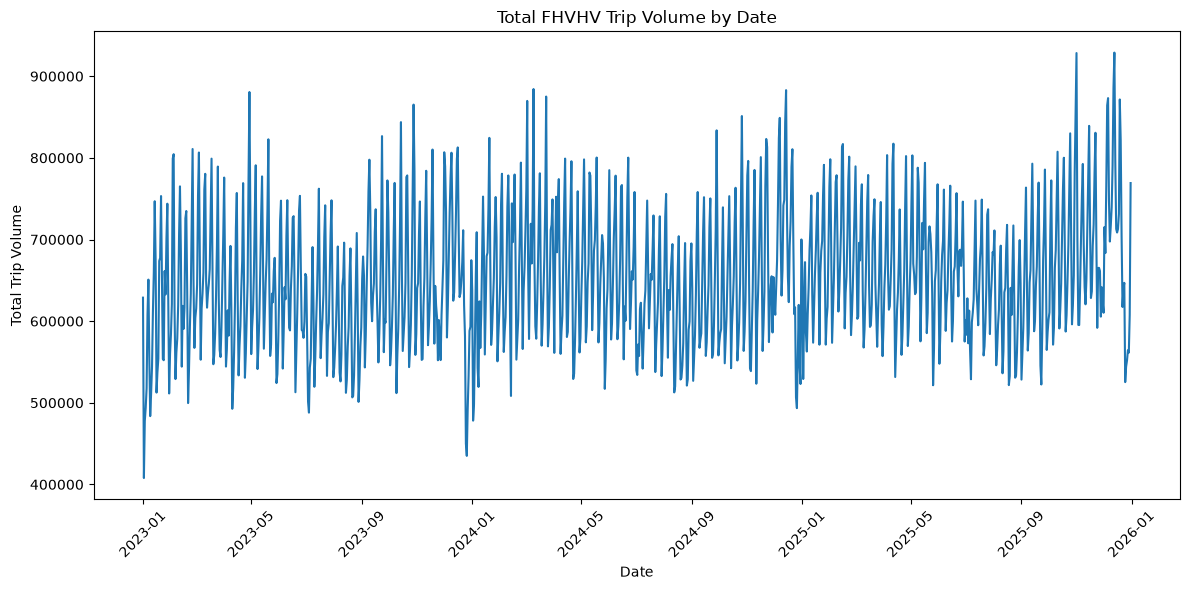

In [26]:
daily_trip_volume = (
    fhvhv_trip_volume
    .groupBy("date")
    .agg(F.sum("trip_volume").alias("total_trip_volume"))
    .orderBy("date")
)
pdf = daily_trip_volume.toPandas()

plt.figure(figsize=(12, 6))
plt.plot(pdf["date"], pdf["total_trip_volume"])
plt.xlabel("Date")
plt.ylabel("Total Trip Volume")
plt.title("Total FHVHV Trip Volume by Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
from utils import add_stations
print('Shape before adding stations:', (yellow_total.count(), len(yellow_total.columns)))
yellow_data_with_stations = add_stations(yellow_total, spark)
print('Shape after adding stations:', (yellow_data_with_stations.count(), len(yellow_data_with_stations.columns)))

Shape before adding stations: (260, 2)
Shape after adding stations: (260, 3)


In [28]:
print('Shape before adding stations:', (daily_taxi_earnings.count(), len(daily_taxi_earnings.columns)))
daily_taxi_earnings = add_stations(daily_taxi_earnings, spark)
print('Shape after adding stations:', (daily_taxi_earnings.count(), len(daily_taxi_earnings.columns)))
daily_taxi_earnings.show(5)

Shape before adding stations: (228261, 3)


Shape after adding stations: (228261, 4)


+----------+------------+------------------+------------+
|       day|PULocationID|      total_amount|num_stations|
+----------+------------+------------------+------------+
|2023-05-01|          95|            381.71|           3|
|2023-05-05|         253|             66.24|           0|
|2023-05-06|         229| 43238.89999999988|           1|
|2023-05-09|         235|             203.7|           2|
|2023-05-12|         219|414.20000000000005|           0|
+----------+------------+------------------+------------+
only showing top 5 rows


In [29]:
# Create a Python dictionary from GeoPandas
borough_mapping = dict(
    zip(geo_data["LocationID"], geo_data["borough"])
)

# Create a Spark map expression
mapping_expr = F.create_map(
    *[
        item
        for location_id, borough in borough_mapping.items()
        for item in (F.lit(int(location_id)), F.lit(borough))
    ]
)

print('Shape before adding Borough column:', (daily_taxi_earnings.count(), len(daily_taxi_earnings.columns)))
# Add Borough column
daily_taxi_earnings_with_station = daily_taxi_earnings.withColumn(
    "Borough",
    mapping_expr[F.col("PULocationID")]
)
print('Shape after adding Borough column:', (daily_taxi_earnings_with_station.count(), len(daily_taxi_earnings_with_station.columns)))
daily_taxi_earnings_with_station.show(5)

Shape before adding Borough column: (228261, 4)


Shape after adding Borough column: (228261, 5)


+----------+------------+------------------+------------+---------+
|       day|PULocationID|      total_amount|num_stations|  Borough|
+----------+------------+------------------+------------+---------+
|2023-05-01|          95|            381.71|           3|   Queens|
|2023-05-05|         253|             66.24|           0|   Queens|
|2023-05-06|         229| 43238.89999999988|           1|Manhattan|
|2023-05-09|         235|             203.7|           2|    Bronx|
|2023-05-12|         219|414.20000000000005|           0|   Queens|
+----------+------------+------------------+------------+---------+
only showing top 5 rows


Shape before grouping: (228261, 5)


Shape after grouping: (11, 2)


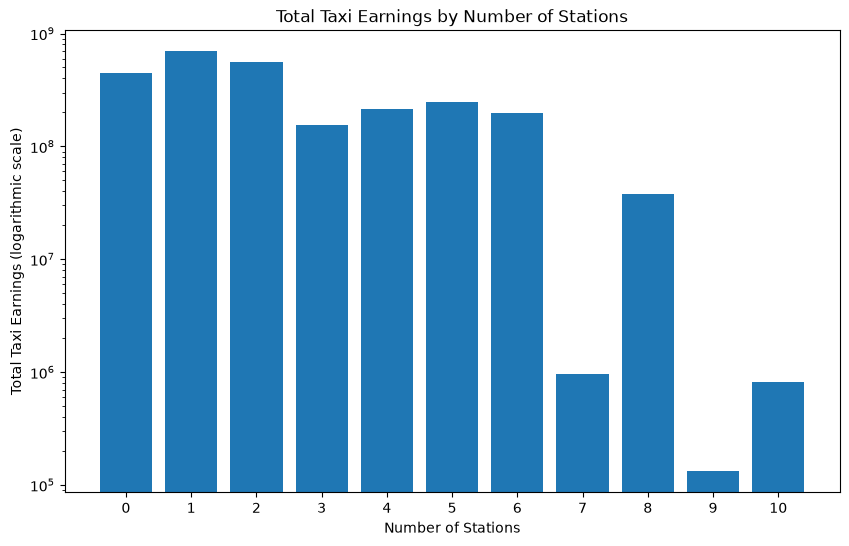

In [30]:
print('Shape before grouping:', (daily_taxi_earnings_with_station.count(), len(daily_taxi_earnings_with_station.columns)))
# Aggregate total trip volume by number of stations
plot_df = (
    daily_taxi_earnings_with_station.groupBy("num_stations")
      .agg(F.sum("total_amount").alias("total_amount"))
      .orderBy("num_stations")
)
print('Shape after grouping:', (plot_df.count(), len(plot_df.columns)))

# Convert to Pandas
pdf = plot_df.toPandas()

# Bar plot
plt.figure(figsize=(10, 6))
plt.bar(
    pdf["num_stations"].astype(str),
    pdf["total_amount"]
)

plt.xlabel("Number of Stations")
plt.ylabel("Total Taxi Earnings (logarithmic scale)")
plt.title("Total Taxi Earnings by Number of Stations")
plt.yscale("log")  # Log scale for better visualization
plt.show()

# Exploring residential factors

In [31]:
residential_data = spark.read.csv('cleaned_data/residential_data.csv', header=True, inferSchema=True)

In [32]:
print('Shape before grouping:', (daily_taxi_earnings_with_station.count(), len(daily_taxi_earnings_with_station.columns)))
daily_earnings_temp= daily_taxi_earnings_with_station.groupby('PULocationID', 'Borough').agg(F.sum('total_amount').alias('total_amount')).orderBy('PULocationID')
print('Shape after grouping:', (daily_earnings_temp.count(), len(daily_earnings_temp.columns)))
daily_earnings_temp.show(1)

Shape before grouping: (228261, 5)


Shape after grouping: (260, 3)


+------------+-------+------------+
|PULocationID|Borough|total_amount|
+------------+-------+------------+
|           1|    EWR|    15697.05|
+------------+-------+------------+
only showing top 1 row


In [33]:
print('Shape before joining:', (residential_data.count(), len(residential_data.columns)), (daily_earnings_temp.count(), len(daily_earnings_temp.columns)))
# join the daily taxi earnings with the residential data on PULocationID
demand_proxy_by_zone = residential_data.join(daily_earnings_temp, residential_data.LocationID == daily_earnings_temp.PULocationID, 'left').drop('PULocationID')
print('Shape after joining:', (demand_proxy_by_zone.count(), len(demand_proxy_by_zone.columns)))
demand_proxy_by_zone.show(2)

Shape before joining: (239, 7) (260, 3)


Shape after joining: (239, 9)


+----------+---------------------+-------------+--------------------+------------+------------------+---------------+---------+------------------+
|LocationID|TotalResidentialUnits|TotalNumBldgs|TotalResidentialArea|TotalLotArea|      AvgNumFloors|NumBuildingLots|  Borough|      total_amount|
+----------+---------------------+-------------+--------------------+------------+------------------+---------------+---------+------------------+
|       4.0|                13758|        564.0|         1.1224175E7|   3847828.0| 5.615800865800866|            465|Manhattan|2748328.6400000006|
|       3.0|                 9674|       6268.0|           9671960.0| 1.6660256E7|1.9509585342333653|           5191|    Bronx| 78936.13999999998|
+----------+---------------------+-------------+--------------------+------------+------------------+---------------+---------+------------------+
only showing top 2 rows


In [34]:
print('Shape before calculating residential_density:', (demand_proxy_by_zone.count(), len(demand_proxy_by_zone.columns)))
# calculate residential_density
demand_proxy_by_zone = demand_proxy_by_zone.withColumn('residential_density', F.col('TotalResidentialUnits') / F.col('NumBuildingLots'))
print('Shape after calculating residential_density:', (demand_proxy_by_zone.count(), len(demand_proxy_by_zone.columns)))

Shape before calculating residential_density: (239, 9)


Shape after calculating residential_density: (239, 10)


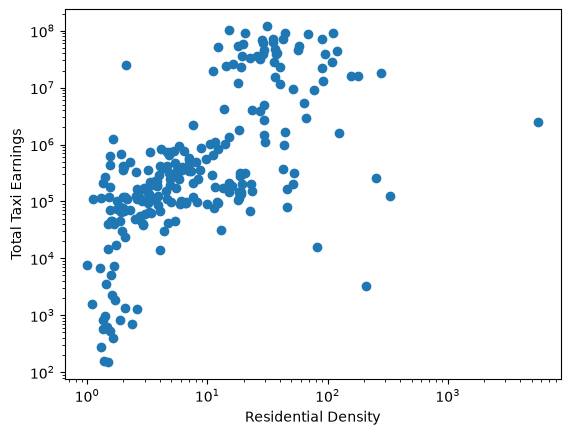

In [35]:
fig, axes = plt.subplots()
plt.scatter(demand_proxy_by_zone.select('residential_density').rdd.flatMap(lambda x: x).collect(),
            demand_proxy_by_zone.select('total_amount').rdd.flatMap(lambda x: x).collect())
plt.xlabel('Residential Density')
plt.ylabel('Total Taxi Earnings')
plt.yscale('log')  # Log scale for better visualization
plt.xscale('log')  # Log scale for better visualization
plt.show()

In [36]:
# calculate correlation between log(residential_density) and log(total_amount)
correlation = demand_proxy_by_zone.select(
    F.log(F.col('residential_density')).alias('log_density'),
    F.log(F.col('total_amount')).alias('log_amount')
).corr('log_density', 'log_amount')

print(f"Correlation: {correlation}")

Correlation: 0.6453235646784844


In [37]:
boroughs = sorted(demand_proxy_by_zone.select('Borough').distinct().rdd.map(lambda row: row[0]).collect())
borough_data_list = []

for borough in boroughs:
    borough_data = demand_proxy_by_zone.filter(demand_proxy_by_zone['Borough'] == borough)
    density_values = borough_data.select('residential_density').rdd.flatMap(lambda x: x).collect()
    borough_data_list.append(density_values)


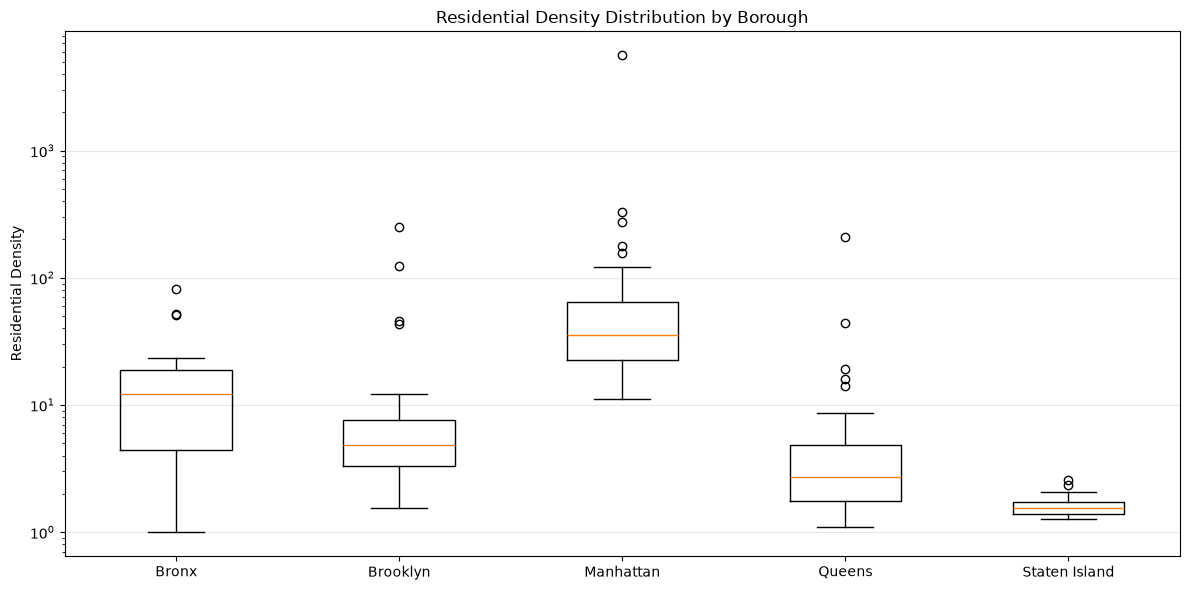

In [38]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot(borough_data_list, label=boroughs)
ax.set_xticklabels(boroughs)
ax.set_ylabel('Residential Density')
ax.set_yscale('log')
ax.set_title('Residential Density Distribution by Borough')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()